**Feature Extraction using PCA**

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from google.colab import files
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

Import Data

In [5]:
Uploaded = files.upload()
filename = list(Uploaded.keys())[0]
df = pd.read_csv(filename, skiprows=4)
df.head()


Saving API_SP.DYN.CDRT.IN_DS2_en_csv_v2_1071.csv to API_SP.DYN.CDRT.IN_DS2_en_csv_v2_1071 (1).csv


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,7.525000,7.347000,7.066000,6.863000,6.689000,6.572000,...,6.594000,6.703000,6.145000,6.842000,8.951000,8.191000,7.582000,7.778000,NaN,NaN
1,Africa Eastern and Southern,AFE,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,20.965499,20.745542,20.443071,20.234375,19.903705,19.767112,...,8.078787,7.673761,7.462467,7.540204,7.913823,7.245335,6.978787,6.915108,NaN,NaN
2,Afghanistan,AFG,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,31.672000,31.129000,30.630000,30.168000,29.672000,29.193000,...,7.315000,7.271000,7.064000,7.565000,8.002000,5.993000,5.797000,5.702000,NaN,NaN
3,Africa Western and Central,AFW,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,26.442827,26.204642,25.726181,25.533288,25.333072,25.096015,...,11.045842,10.759497,10.717106,10.470300,10.418611,10.357379,9.659170,9.571777,NaN,NaN
4,Angola,AGO,"Death rate, crude (per 1,000 people)",SP.DYN.CDRT.IN,27.055000,28.075000,27.871000,27.648000,27.370000,27.087000,...,8.192000,7.928000,7.701000,7.628000,7.619000,7.097000,6.925000,6.840000,NaN,NaN


Select A Country

In [13]:
mort = df[df["Country Name"] == "Bangladesh"]

year_cols = [col for col in mort.columns if col.isnumeric()]

mort_ts = (
    mort[year_cols]
    .T
    .astype(float)
)

mort_ts.index = mort_ts.index.astype(int)
mort_ts.columns = ["DeathRate"]
mort_ts = mort_ts.dropna()

Data Cleaning

In [14]:
mort_ts = mort_ts.dropna()

Remove Outliers

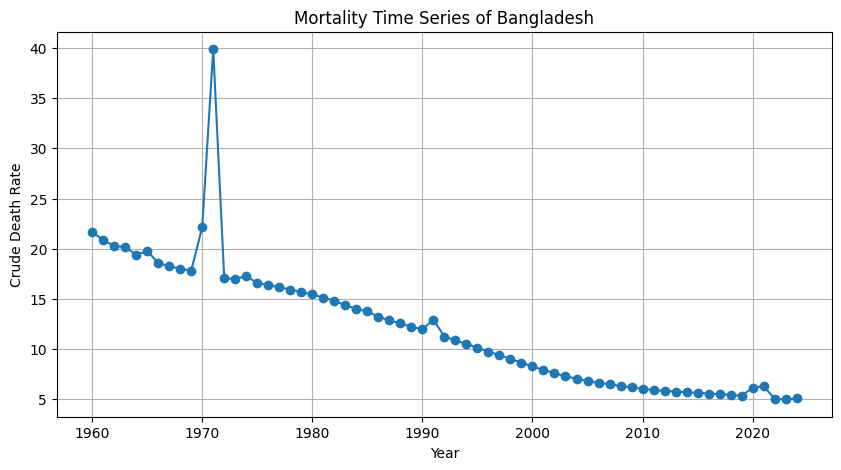

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(mort_ts.index, mort_ts["DeathRate"], marker="o")
plt.title("Mortality Time Series of Bangladesh")
plt.xlabel("Year")
plt.ylabel("Crude Death Rate")
plt.grid(True)
plt.show()


In [16]:
Q1 = mort_ts["DeathRate"].quantile(0.25)
Q3 = mort_ts["DeathRate"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = mort_ts[
    (mort_ts["DeathRate"] < lower_bound) |
    (mort_ts["DeathRate"] > upper_bound)
]

outliers

,DeathRate
1971,39.876


In [17]:
mort_ts_capped = mort_ts.copy()

mort_ts_capped["DeathRate"] = mort_ts_capped["DeathRate"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [18]:
mort_ts["zscore"] = stats.zscore(mort_ts["DeathRate"])

outliers_z = mort_ts[abs(mort_ts["zscore"]) > 3]
outliers_z

,DeathRate,zscore
1971,39.876,4.421987


Exploratory Data Analysis (EDA) on Mortality Rates

In [22]:
mort_ts_clean.describe()

,DeathRate
count,65.000000
mean,11.977692
std,5.817504
min,5.010000
25%,6.319000
50%,11.243000
75%,16.379000
max,31.469000


Moving Average

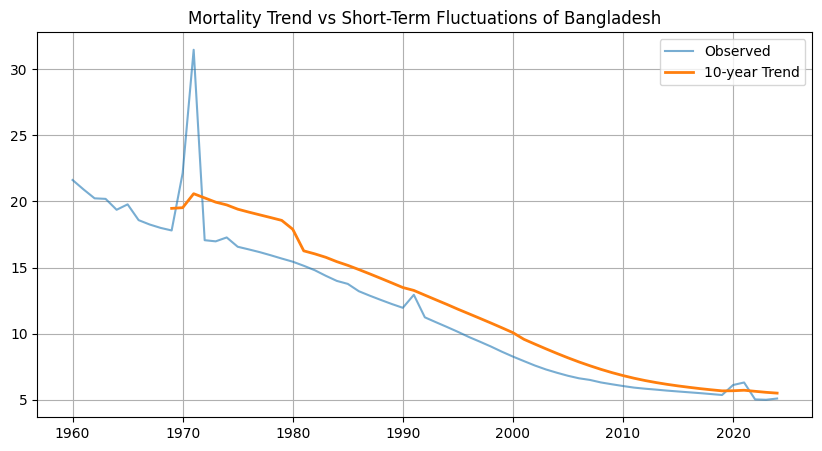

In [23]:
mort_ts_clean["Trend_10"] = mort_ts_clean["DeathRate"].rolling(10).mean()

plt.figure(figsize=(10,5))
plt.plot(mort_ts_clean["DeathRate"], alpha=0.6, label="Observed")
plt.plot(mort_ts_clean["Trend_10"], linewidth=2, label="10-year Trend")
plt.legend()
plt.title("Mortality Trend vs Short-Term Fluctuations of Bangladesh")
plt.grid(True)
plt.show()

PCA

In [20]:
mort_ts_original = mort_ts.copy()
mort_ts_clean = mort_ts_capped.copy()

log_mort = np.log(mort_ts_clean["DeathRate"].values)
Z = log_mort - log_mort.mean()

# Reshape to 2D
Z_2d = Z.reshape(-1, 1)

# Apply PCA
pca = PCA(n_components=1)
k_t = pca.fit_transform(Z_2d)

# Explained variance
print("Variance explained:", pca.explained_variance_ratio_[0])


Variance explained: 1.0


Outlier Impact Analysis

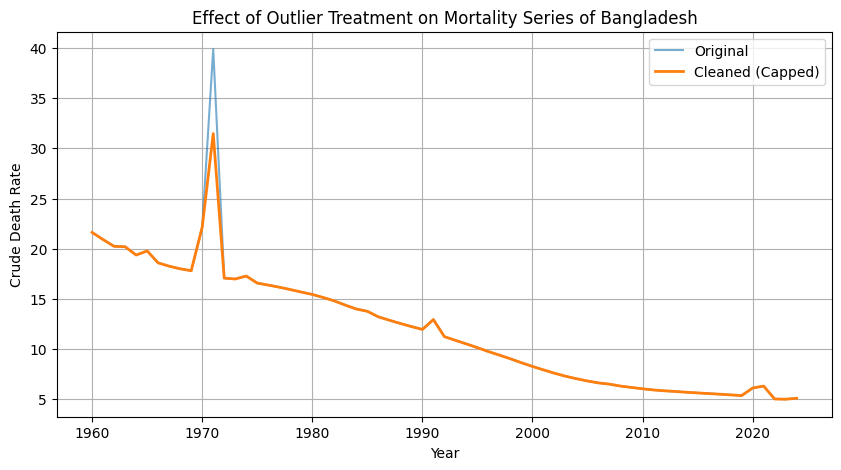

In [21]:
plt.figure(figsize=(10,5))
plt.plot(mort_ts_original.index, mort_ts_original["DeathRate"],
         label="Original", alpha=0.6)
plt.plot(mort_ts_clean.index, mort_ts_clean["DeathRate"],
         label="Cleaned (Capped)", linewidth=2)
plt.legend()
plt.title("Effect of Outlier Treatment on Mortality Series of Bangladesh")
plt.xlabel("Year")
plt.ylabel("Crude Death Rate")
plt.grid(True)
plt.show()


Stationarity Testing

In [27]:
# Convert feature to time series
k_series = pd.Series(
    k_t.flatten(),
    index=pd.to_datetime(mort_ts.index, format="%Y")
)

# Augmented Dickey-Fuller test
adf_result = adfuller(k_series)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -0.17961230172004206
p-value: 0.940908545652198


Forecasting the Extracted Feature using ARIMA

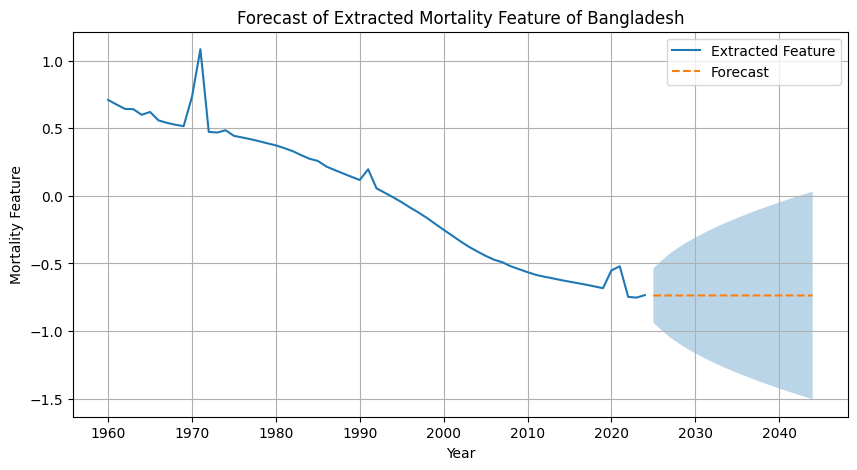

In [28]:
# Year start
k_series = k_series.asfreq("YS")  # Year start

# Fit ARIMA model
model = ARIMA(k_series, order=(1, 1, 0))
results = model.fit()

# Forecast
forecast = results.get_forecast(steps=20)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_series, label="Extracted Feature")
plt.plot(forecast_mean, linestyle="--", label="Forecast")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)
plt.xlabel("Year")
plt.ylabel("Mortality Feature")
plt.title("Forecast of Extracted Mortality Feature of Bangladesh")
plt.legend()
plt.grid(True)
plt.show()

ARIMA Residual Diagnostics

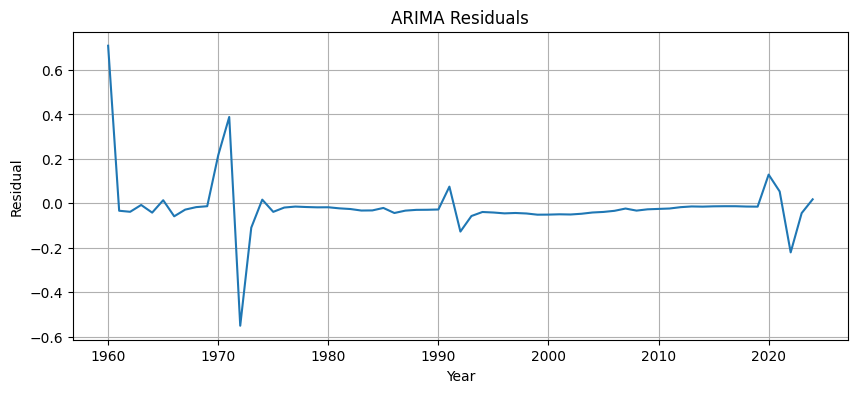

<Figure size 1000x400 with 0 Axes>

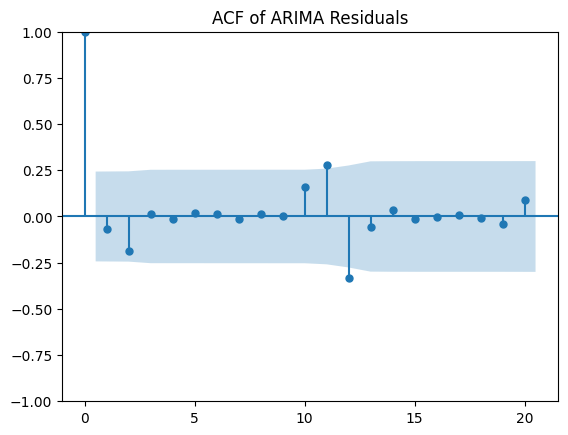

In [29]:
# Residuals from ARIMA model
residuals = results.resid

# Plot residuals
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# ACF of residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20)
plt.title("ACF of ARIMA Residuals")
plt.show()


Insurance Pricing

In [30]:
# Baseline mortality
baseline_mortality = mort_ts_clean["DeathRate"].iloc[-1] / 1000  # per person

# Convert latent feature to mortality rate forecast
alpha = 0.05  # sensitivity parameter (illustrative)

mortality_forecast = baseline_mortality * np.exp(alpha * forecast_mean)

# Compute Survival Probabilities
survival_prob = np.exp(-mortality_forecast)

# Term Insurance Assumptions
term = 10
benefit = 100_000
i = 0.04
v = 1 / (1 + i)

discount_factors = v ** np.arange(1, term + 1)

# Year‑specific death probabilities
death_prob = 1 - survival_prob.iloc[:term]

# Expected Present Value (EPV) of benefit
EPV_benefit = np.sum(
    benefit * discount_factors * death_prob
)

# Net Single Premium
net_single_premium = EPV_benefit
net_single_premium

# Risk Margin
upper_mortality = baseline_mortality * np.exp(alpha * forecast_ci.iloc[:, 1])
upper_death_prob = 1 - np.exp(-upper_mortality.iloc[:term])

EPV_upper = np.sum(
    benefit * discount_factors * upper_death_prob
)

risk_margin = EPV_upper - EPV_benefit
risk_margin

# Final Gross Premium
expense_loading = 0.10  # 10%

gross_premium = (net_single_premium + risk_margin) * (1 + expense_loading)
gross_premium

print(f"Net Single Premium     : BDT {net_single_premium:,.2f} per policy")
print(f"Risk Margin            : BDT {risk_margin:,.2f} per policy")
print(f"Expense Loading (10%)  : BDT {(net_single_premium + risk_margin) * expense_loading:,.2f} per policy")
print(f"Gross Premium          : BDT {gross_premium:,.2f} per policy")


Net Single Premium     : BDT 3,981.01 per policy
Risk Margin            : BDT 77.06 per policy
Expense Loading (10%)  : BDT 405.81 per policy
Gross Premium          : BDT 4,463.88 per policy
